In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile

In [2]:
def scan_f3_leakage_phase(
    num_angles=360,
    encoding=None,
    compile_fn=None,
    basis_gates=("cz", "rz", "sx", "x"),
    optimization_level=3,
    seed=0,
):

    if encoding is None:
        encoding = np.eye(4, 3, dtype=complex)

    E = np.asarray(encoding, dtype=complex)

    omega = np.exp(2j * np.pi / 3)

    F3 = np.array(
        [
            [omega ** (j * k) for k in range(3)]
            for j in range(3)
        ],
        dtype=complex,
    ) / np.sqrt(3)

    P_code = E @ E.conj().T
    P_free = np.eye(4, dtype=complex) - P_code

    results = []

    phis = np.linspace(0.0, 2.0 * np.pi, num_angles, endpoint=False)

    for phi in phis:
        # Na przestrzeni kodowej działa F3, a na wolnym wymiarze exp(i*phi).
        U_phi = (
            E @ F3 @ E.conj().T
            + np.exp(1j * phi) * P_free
        )

        qc = QuantumCircuit(2)
        qc.unitary(U_phi, [0, 1], label=f"F3_phi={phi:.4f}")

        if compile_fn is None:
            compiled = transpile(
                qc,
                basis_gates=list(basis_gates),
                optimization_level=optimization_level,
                seed_transpiler=seed,
            )
        else:
            compiled = compile_fn(qc)

        two_qubit_gates = sum(
            instruction.operation.num_qubits == 2
            for instruction in compiled.data
        )

        one_qubit_gates = sum(
            instruction.operation.num_qubits == 1
            for instruction in compiled.data
        )

        results.append(
            {
                "phi": float(phi),
                "phi_over_pi": float(phi / np.pi),
                "two_qubit_gates": int(two_qubit_gates),
                "one_qubit_gates": int(one_qubit_gates),
                "depth": int(compiled.depth()),
                "size": int(compiled.size()),
                "unitary": U_phi,
                "circuit": compiled,
            }
        )

    # Priorytet: liczba bramek 2Q, potem depth, potem całkowity rozmiar.
    best = min(
        results,
        key=lambda r: (
            r["two_qubit_gates"],
            r["depth"],
            r["size"],
        ),
    )

    baseline = results[0]  # phi = 0, czyli standardowe F3 ⊕ 1

    print(
        "phi = 0: "
        f"2Q={baseline['two_qubit_gates']}, "
        f"depth={baseline['depth']}, "
        f"size={baseline['size']}"
    )

    print(
        "najlepszy: "
        f"phi={best['phi']:.8f} "
        f"({best['phi_over_pi']:.6f} pi), "
        f"2Q={best['two_qubit_gates']}, "
        f"depth={best['depth']}, "
        f"size={best['size']}"
    )

    return best, results

phi = 0: 2Q=3, depth=19, size=31
najlepszy: phi=5.75958653 (1.833333 pi), 2Q=2, depth=15, size=28


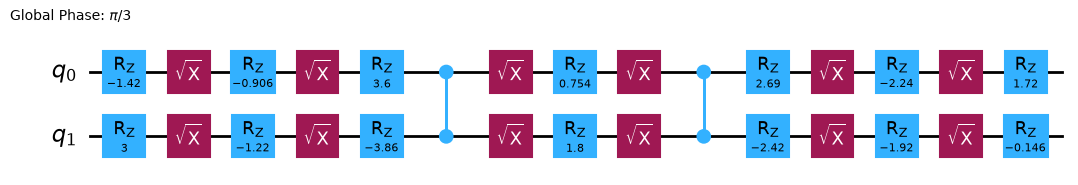

In [19]:
best, results = scan_f3_leakage_phase(num_angles=360)

best["unitary"]
best["circuit"].draw("mpl")

In [9]:
from qiskit import qpy

with open("C:/Users/szymo/QuditsOnQubits/QuditsOnQubits/quantum_circuits/Fgate3.qpy", 'rb') as fd:
    F3 = qpy.load(fd)[0]

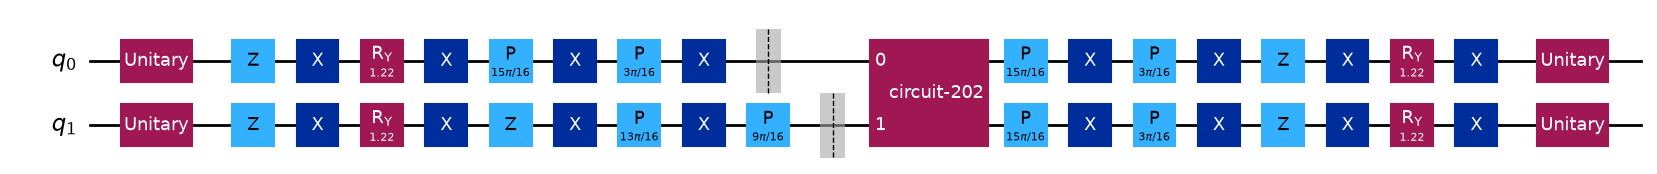

In [12]:
F3.decompose().draw("mpl")

In [13]:
basis_gates=("cz", "rz", "sx", "x")

compiled = transpile(
                F3,
                basis_gates=list(basis_gates),
                optimization_level=3,
                seed_transpiler=7,
            )

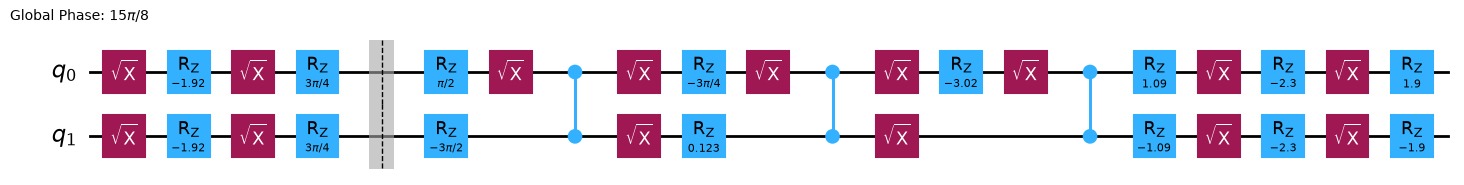

In [15]:
compiled.draw("mpl")

In [16]:
compiled.depth()

20

In [18]:
best["circuit"].depth()

19